In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

In [4]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
df.shape

(100000, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [8]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [10]:
df.dtypes

gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

In [12]:
df["gender"].unique()


<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [13]:
df["smoking_history"].unique()

<StringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str

In [14]:
df["gender"].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

In [15]:
df["smoking_history"].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [16]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(3854)

In [18]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
47708,Female,2.0,0,0,No Info,27.32,5.0,158,0
59468,Female,2.0,0,0,No Info,27.32,5.0,158,0
62073,Female,2.0,0,0,No Info,27.32,6.0,85,0
67439,Female,2.0,0,0,No Info,27.32,6.0,85,0
23617,Female,2.0,0,0,No Info,27.32,6.0,145,0
67234,Female,2.0,0,0,No Info,27.32,6.0,145,0
90685,Female,2.0,0,0,No Info,27.32,6.2,145,0
97294,Female,2.0,0,0,No Info,27.32,6.2,145,0
46785,Female,2.0,0,0,No Info,27.32,6.5,155,0
89701,Female,2.0,0,0,No Info,27.32,6.5,155,0


In [19]:
df[df['age'] < 3]['bmi'].value_counts().head(10)

bmi
27.32    386
16.70     15
17.97     13
17.30     13
15.80     12
17.43     12
16.30     12
15.10     12
17.03     12
17.22     11
Name: count, dtype: int64

In [20]:
total_young = (df['age'] < 3).sum()
print(total_young)
print(386 / total_young * 100)

3287
11.743230909644051


In [21]:
total_adults = (df['age'] >= 18).sum()
adults_2732 = ((df['age'] >= 18) & (df['bmi'] == 27.32)).sum()
print(total_adults, adults_2732, adults_2732/total_adults*100)

82781 22307 26.94700474746621


In [22]:
df['bmi'].value_counts().head(5)
(df['bmi'] == 27.32).sum() / len(df) * 100

np.float64(25.495)

In [23]:
import matplotlib.pyplot as plt

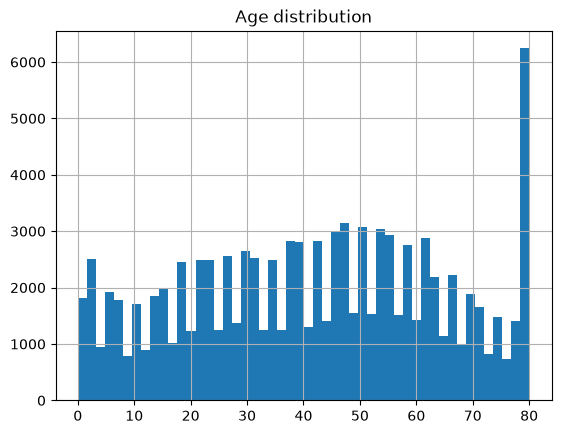

In [27]:
df["age"].hist(bins=50)
plt.title('Age distribution')
plt.show()

In [28]:
(df['age'] == 80).sum()

np.int64(5621)

In [29]:
df['age'].max()


np.float64(80.0)

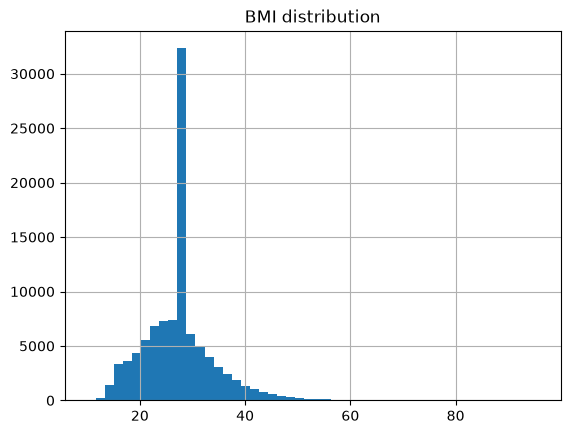

In [30]:
df["bmi"].hist(bins=50)
plt.title("BMI distribution")
plt.show()

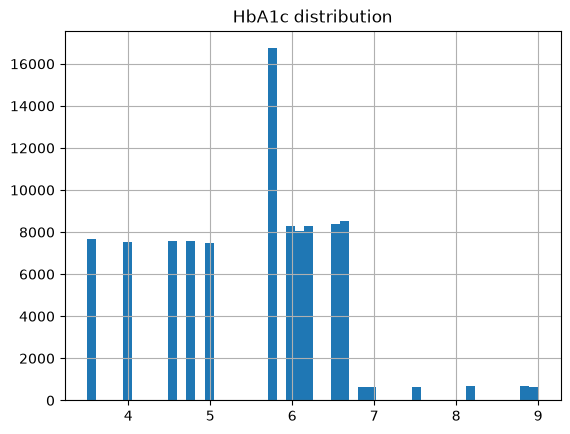

In [31]:
df['HbA1c_level'].hist(bins=50)
plt.title('HbA1c distribution')
plt.show()

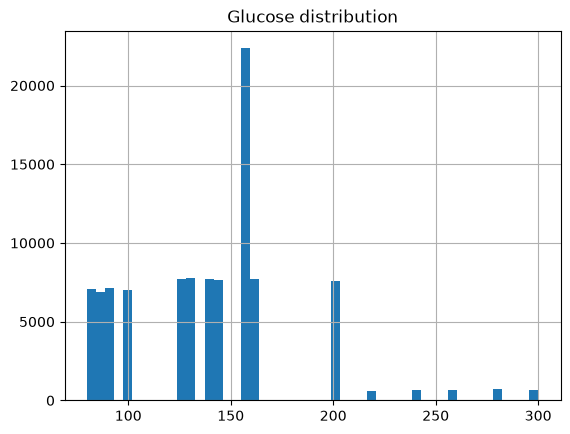

In [32]:
df['blood_glucose_level'].hist(bins=50)
plt.title('Glucose distribution')
plt.show()

In [33]:
df['HbA1c_level'].value_counts().sort_index()

HbA1c_level
3.5    7662
4.0    7542
4.5    7585
4.8    7597
5.0    7471
5.7    8413
5.8    8321
6.0    8295
6.1    8048
6.2    8269
6.5    8362
6.6    8540
6.8     642
7.0     634
7.5     643
8.2     661
8.8     661
9.0     654
Name: count, dtype: int64

In [34]:
df['blood_glucose_level'].value_counts().sort_index()

blood_glucose_level
80     7106
85     6901
90     7112
100    7025
126    7702
130    7794
140    7732
145    7679
155    7575
158    7026
159    7759
160    7712
200    7600
220     603
240     636
260     635
280     729
300     674
Name: count, dtype: int64

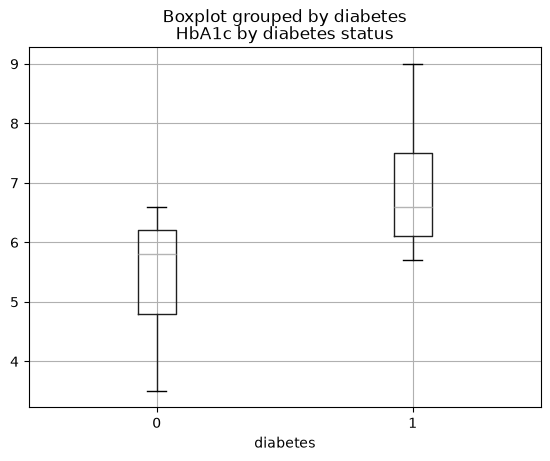

In [35]:
df.boxplot(column='HbA1c_level', by='diabetes')
plt.title('HbA1c by diabetes status')
plt.show()

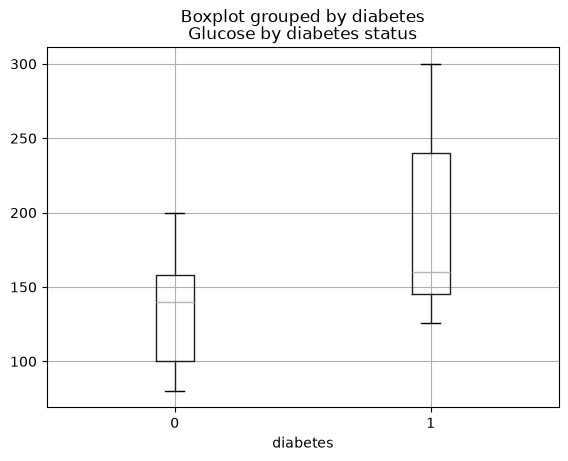

In [36]:
df.boxplot(column='blood_glucose_level', by='diabetes')
plt.title('Glucose by diabetes status')
plt.show()

In [37]:
pd.crosstab(df['smoking_history'], df['diabetes'], normalize='index')

diabetes,0,1
smoking_history,,
No Info,0.959404,0.040596
current,0.897911,0.102089
ever,0.882118,0.117882
former,0.829983,0.170017
never,0.904659,0.095341
not current,0.892973,0.107027


In [38]:
df.groupby('smoking_history')['age'].mean()

smoking_history
No Info        33.538037
current        44.063696
ever           49.136863
former         57.061698
never          43.891491
not current    47.689611
Name: age, dtype: float64

In [39]:
pd.crosstab(df['gender'], df['diabetes'], normalize='index')

diabetes,0,1
gender,,
Female,0.923811,0.076189
Male,0.902510,0.097490
Other,1.000000,0.000000


In [40]:
df.shape

(100000, 9)

In [41]:
df.duplicated().sum()

np.int64(3854)

In [42]:
df_clean = df.drop_duplicates()
df_clean.shape

(96146, 9)

In [43]:
df_clean.duplicated().sum()

np.int64(0)

In [44]:
df_clean = df_clean[df_clean['gender'] != 'Other']
df_clean.shape
df_clean['gender'].value_counts()

gender
Female    56161
Male      39967
Name: count, dtype: int64

In [45]:
df_clean[df_clean['bmi'] == 27.32]['age'].mean()

np.float64(43.93437739507826)

In [46]:
print(df_clean[df_clean['bmi'] == 27.32]['age'].mean())
print(df_clean[df_clean['bmi'] != 27.32]['age'].mean())

43.93437739507826
41.17485880030617


In [47]:
(df_clean['age'] == 80).sum()


np.int64(4932)

In [48]:
for col in ['bmi', 'HbA1c_level', 'blood_glucose_level']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(col, "outliers:", outliers, "| bounds:", lower, upper)

bmi outliers: 5354 | bounds: 13.709999999999997 39.55
HbA1c_level outliers: 1312 | bounds: 2.6999999999999993 8.3
blood_glucose_level outliers: 2031 | bounds: 11.5 247.5


In [49]:
Q1 = df_clean['HbA1c_level'].quantile(0.25)
Q3 = df_clean['HbA1c_level'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outlier_rows = df_clean[df_clean['HbA1c_level'] > upper]
print(outlier_rows['diabetes'].value_counts(normalize=True))

diabetes
1    1.0
Name: proportion, dtype: float64


In [50]:
Q1 = df_clean['blood_glucose_level'].quantile(0.25)
Q3 = df_clean['blood_glucose_level'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

outlier_rows = df_clean[df_clean['blood_glucose_level'] > upper]
print(outlier_rows['diabetes'].value_counts(normalize=True))

diabetes
1    1.0
Name: proportion, dtype: float64


In [51]:
Q1 = df_clean['bmi'].quantile(0.25)
Q3 = df_clean['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_rows = df_clean[(df_clean['bmi'] < lower) | (df_clean['bmi'] > upper)]
print(outlier_rows['diabetes'].value_counts(normalize=True))
print(outlier_rows.shape)

diabetes
0    0.763355
1    0.236645
Name: proportion, dtype: float64
(5354, 9)


In [52]:
df_clean.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='str')

In [56]:
!py -m pip install scikit-learn

                                              0.0/8.3 MB ? eta -:--:--
                                              0.0/8.3 MB 660.6 kB/s eta 0:00:13
                                              0.1/8.3 MB 660.6 kB/s eta 0:00:13
                                              0.1/8.3 MB 655.4 kB/s eta 0:00:13
                                              0.1/8.3 MB 774.0 kB/s eta 0:00:11
                                              0.2/8.3 MB 794.9 kB/s eta 0:00:11
     -                                        0.2/8.3 MB 901.1 kB/s eta 0:00:09
     -                                        0.3/8.3 MB 827.5 kB/s eta 0:00:10
     -                                        0.3/8.3 MB 820.5 kB/s eta 0:00:10
     -                                        0.3/8.3 MB 803.7 kB/s eta 0:00:10
     -                                        0.3/8.3 MB 785.7 kB/s eta 0:00:11
     -                                        0.3/8.3 MB 776.5 kB/s eta 0:00:11
     -                                        0.4


[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: C:\Users\sakan\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd

df = pd.read_csv('diabetes_prediction_dataset.csv')
df_clean = df.drop_duplicates()
df_clean = df_clean[df_clean['gender'] != 'Other']
df_clean.shape

(96128, 9)

In [2]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('diabetes', axis=1)
y = df_clean['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(76902, 8) (19226, 8)
diabetes
0    0.911758
1    0.088242
Name: proportion, dtype: float64
diabetes
0    0.911786
1    0.088214
Name: proportion, dtype: float64


In [3]:
X_train_encoded = pd.get_dummies(X_train, columns=['gender', 'smoking_history'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['gender', 'smoking_history'], drop_first=True)

print(X_train_encoded.columns.tolist())
print(X_train_encoded.shape, X_test_encoded.shape)

['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']
(76902, 12) (19226, 12)


In [4]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

scaler = StandardScaler()

X_train_encoded[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols] = scaler.transform(X_test_encoded[numeric_cols])

print(X_train_encoded[numeric_cols].describe())

                age           bmi   HbA1c_level  blood_glucose_level
count  7.690200e+04  7.690200e+04  7.690200e+04         7.690200e+04
mean   3.186734e-16  2.272938e-16 -3.156243e-16        -1.129078e-16
std    1.000007e+00  1.000007e+00  1.000007e+00         1.000007e+00
min   -1.854238e+00 -2.556311e+00 -1.895902e+00        -1.424412e+00
25%   -7.905821e-01 -5.810925e-01 -6.839268e-01        -9.351977e-01
50%    5.429504e-02  2.897969e-03  2.483618e-01         4.323172e-02
75%    7.657706e-01  3.754691e-01  6.212772e-01         5.079857e-01
max    1.699582e+00  1.011111e+01  3.231685e+00         3.956950e+00


In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_encoded, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [7]:
y_pred = model.predict(X_test_encoded)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.958805783834391
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17530
           1       0.86      0.64      0.73      1696

    accuracy                           0.96     19226
   macro avg       0.91      0.81      0.85     19226
weighted avg       0.96      0.96      0.96     19226



In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[17352   178]
 [  614  1082]]


In [10]:
model_balanced = LogisticRegression(random_state=42, class_weight='balanced')
model_balanced.fit(X_train_encoded, y_train)

y_pred_balanced = model_balanced.predict(X_test_encoded)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.885103505669406
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     17530
           1       0.43      0.88      0.57      1696

    accuracy                           0.89     19226
   macro avg       0.71      0.88      0.75     19226
weighted avg       0.94      0.89      0.90     19226



In [11]:
import pandas as pd

coefficients = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'coefficient': model.coef_[0]
})
coefficients = coefficients.sort_values('coefficient', ascending=False)
print("Intercept (b0):", model.intercept_[0])
print(coefficients)

Intercept (b0): -5.832066968758916
                        feature  coefficient
4                   HbA1c_level     2.510446
5           blood_glucose_level     1.369120
0                           age     1.080888
1                  hypertension     0.733852
2                 heart_disease     0.702337
7       smoking_history_current     0.619642
3                           bmi     0.600550
9        smoking_history_former     0.521432
8          smoking_history_ever     0.496899
10        smoking_history_never     0.492927
11  smoking_history_not current     0.481110
6                   gender_Male     0.311151


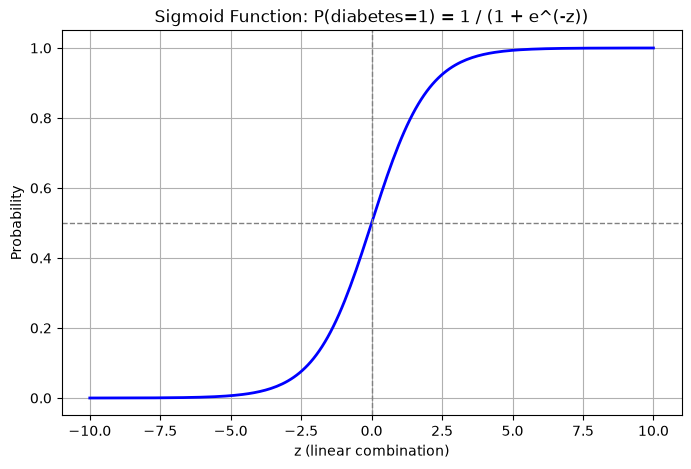

In [13]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid, color='blue', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Sigmoid Function: P(diabetes=1) = 1 / (1 + e^(-z))')
plt.xlabel('z (linear combination)')
plt.ylabel('Probability')
plt.grid(True)
plt.show()

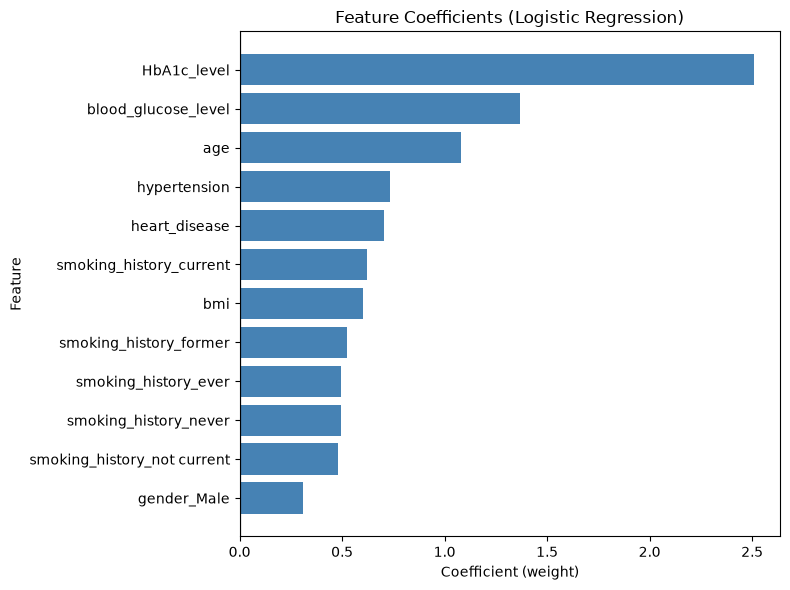

In [14]:
coefficients_sorted = coefficients.sort_values('coefficient')

plt.figure(figsize=(8, 6))
plt.barh(coefficients_sorted['feature'], coefficients_sorted['coefficient'], color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients (Logistic Regression)')
plt.xlabel('Coefficient (weight)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [15]:
new_patient = pd.DataFrame({
    'gender': ['Female'],
    'age': [45],
    'hypertension': [0],
    'heart_disease': [0],
    'smoking_history': ['never'],
    'bmi': [28.5],
    'HbA1c_level': [6.8],
    'blood_glucose_level': [160]
})

new_patient

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,45,0,0,never,28.5,6.8,160


In [16]:
new_patient_encoded = pd.get_dummies(new_patient, columns=['gender', 'smoking_history'])
new_patient_encoded = new_patient_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

new_patient_encoded

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,45,0,0,28.5,6.8,160,0,0,0,0,True,0


In [17]:
new_patient_encoded[numeric_cols] = scaler.transform(new_patient_encoded[numeric_cols])

new_patient_encoded

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0.143229,0,0,0.177356,1.18065,0.532446,0,0,0,0,True,0


In [18]:
prediction = model.predict(new_patient_encoded)
probability = model.predict_proba(new_patient_encoded)

print("Prediction (0=healthy, 1=diabetes):", prediction[0])
print("Probability [P(0), P(1)]:", probability[0])

Prediction (0=healthy, 1=diabetes): 0
Probability [P(0), P(1)]: [0.79977231 0.20022769]
